In [1]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
from tqdm import tqdm
import glob
import re

from datetime import datetime
from tools import time_from_attr, open_L2_CLOUD_GPC

# import warnings
# warnings.filterwarnings("ignore")

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
bbox = (-180, -90, 180, 90)
tspan = ("2024-05-1", "2024-05-31")

results = earthaccess.search_data(
    short_name="PACE_HARP2_L3M_CLOUD_GPC",
    bounding_box=bbox,    
    temporal=tspan,
    granule_name="*.DAY.*.1deg.*"
)
print(len(results))

26


In [ ]:
# files= earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0")

In [2]:
path = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/" \
        "PACE_OCI.20240501.L3m.DAY.CLOUD.V3_1.1deg.nc"
print(path)

/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/PACE_OCI.20240501.L3m.DAY.CLOUD.V3_1.1deg.nc


In [3]:
path_H = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0/" \
         "PACE_HARP2.20240501.L3m.DAY.CLOUD_GPC.V3_0.1deg.nc"
print(path_H)

/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0/PACE_HARP2.20240501.L3m.DAY.CLOUD_GPC.V3_0.1deg.nc


In [4]:
dataset = xr.open_dataset(path)

In [5]:
dataset_H = xr.open_dataset(path_H)

In [6]:
def Nd_adiabatic_model(tau, re, k = 0.8, Cw = 0.0020, fad = 0.7, Qe = 2.0):   
 
    """
    tau: cloud optical thickness (τ) [unitless]
    re: cloud effective radius [µm]
    fad : adiabaticity of cloud [unitless]
    Cw:   lapse rate of water content [g/m^4]
    k:    disperson const rv^3 = k * re^3
    Qe:  extinction efficiency [unitless]

    """
    C = np.sqrt(5)/(2.0*np.pi*k)
    re_m = re*1e-6                      # change unit of re from um to m
    rho  = 1e6                          # density of water [g/m^3]
    CDNC = C * np.sqrt(fad*Cw*tau/Qe/rho/(re_m**5)) * 1e-6
    return CDNC

In [7]:
# Nd1 = Nd_adiabatic_model(20, 5)
# Nd2 = Nd_adiabatic_model(20, 30)
# Nd3 = Nd_adiabatic_model(20, 0.5*(5+30))
# print(Nd1, Nd2, Nd3, 0.5*(Nd1+Nd2))

In [8]:
Nd = Nd_adiabatic_model(dataset.cot_21_water, dataset.cer_21_water)
# Nd = Nd_adiabatic_model(dataset.cot_21_water, dataset_H.cloud_bow_droplet_effective_radius, dataset_H.cloud_bow_droplet_effective_variance)

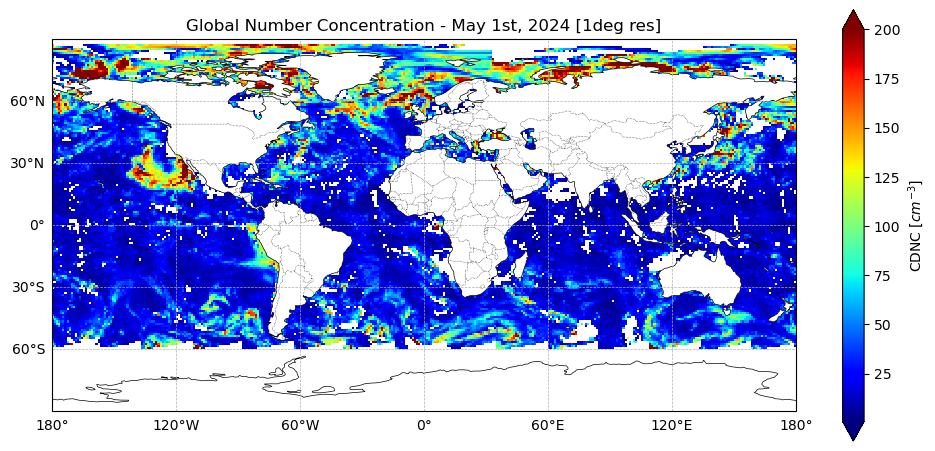

In [9]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

Nd.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', vmax=200, 
                   cbar_kwargs={'label': r'CDNC [$cm^{-3}$]', 'shrink': 0.7, 'extend':'both'}) 

ax.coastlines(linewidth=0.5, color='k')
ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4, zorder=2)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Global Number Concentration - May 1st, 2024 [1deg res]', fontsize=12, color='k', fontweight='normal')
plt.show()

## Nd Monthly Average (from daily Nd values)

In [10]:
path_OCI = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L3M_CLOUD_v3_1/"
files_O = sorted(glob.glob(path_OCI + "PACE_OCI.202405*.L3m.DAY.CLOUD.V3_1.1deg.nc"))

print(len(files_O))  

26


In [11]:
path_HARP2 = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L3M_CLOUD_GPC_v3_0/"
files_H = sorted(glob.glob(path_HARP2 + "PACE_HARP2.202405*.L3m.DAY.CLOUD_GPC.V3_0.1deg.nc"))

print(len(files_H))  

26


In [12]:
ds_O = xr.open_mfdataset(files_O, combine='nested', concat_dim='time')

In [13]:
ds_H = xr.open_mfdataset(files_H, combine='nested', concat_dim='time')

### Nd(OCI_cot, OCI_cer) 

In [14]:
def Nd_adiabatic_model(tau, re, k = 0.8, Cw = 0.0020, fad = 0.7, Qe = 2.0):   
 
    """
    tau: cloud optical thickness (τ) [unitless]
    re: cloud effective radius [µm]
    fad : adiabaticity of cloud [unitless]
    Cw:   lapse rate of water content [g/m^4]
    k:    disperson const rv^3 = k * re^3
    Qe:  extinction efficiency [unitless]

    """
    C = np.sqrt(5)/(2.0*np.pi*k)
    re_m = re*1e-6                      # change unit of re from um to m
    rho  = 1e6                          # density of water [g/m^3]
    CDNC = C * np.sqrt(fad*Cw*tau/Qe/rho/(re_m**5)) * 1e-6
    return CDNC

In [15]:
Nd = Nd_adiabatic_model(ds_O.cot_21_water, ds_O.cer_21_water)

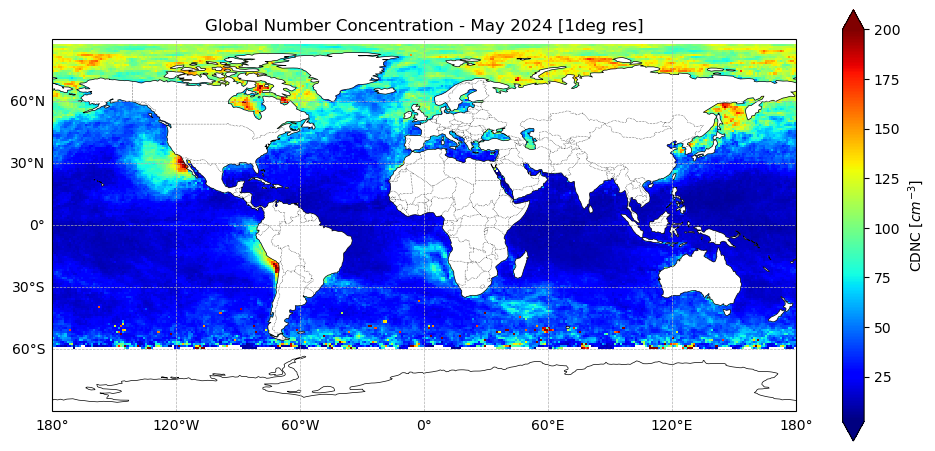

min Nd is 2.477558111510727
max Nd is 2332.2877865524474


In [16]:
Nd_monthly_mean = Nd.mean(dim='time', skipna=True)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

Nd_monthly_mean.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', vmax=200, 
                                cbar_kwargs={'label': r'CDNC [$cm^{-3}$]', 'shrink': 0.7, 'extend':'both'})

ax.coastlines(linewidth=0.5, color='k')
ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Global Number Concentration - May 2024 [1deg res]', fontsize=12)

plt.show()


print('min Nd is', np.nanmin(Nd_monthly_mean))
print('max Nd is', np.nanmax(Nd_monthly_mean))

### Nd(OCI_cot, HARP2_cer) 

In [17]:
Nd = Nd_adiabatic_model(ds_O.cot_21_water, ds_H.cloud_bow_droplet_effective_radius)

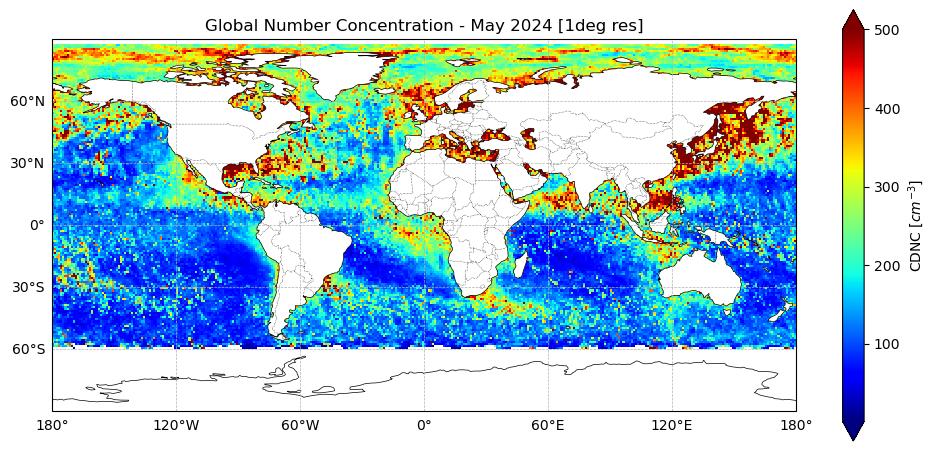

min Nd is 1.222896686269945
max Nd is 2860.4971332849664


In [18]:
Nd_monthly_mean = Nd.mean(dim='time', skipna=True)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

Nd_monthly_mean.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', vmax=500, 
                                cbar_kwargs={'label': r'CDNC [$cm^{-3}$]', 'shrink': 0.7, 'extend':'both'})

ax.coastlines(linewidth=0.5, color='k')
ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Global Number Concentration - May 2024 [1deg res]', fontsize=12)

plt.show()


print('min Nd is', np.nanmin(Nd_monthly_mean))
print('max Nd is', np.nanmax(Nd_monthly_mean))

### Nd(OCI_cot, HARP2_cer, HARP2_cev ≤ 0.33) 

In [19]:
  def Nd_adiabatic_model_ve(tau, re, ve, Cw = 0.0020, fad = 0.7, Qe = 2.0):  
      
    """
    tau: cloud optical thickness (τ) [unitless]
    re: cloud effective radius [µm]
    fad : adiabaticity of cloud [unitless]
    Cw:   lapse rate of water content [g/m^4]
    k:    disperson const rv^3 = k * re^3
    Qe:  extinction efficiency [unitless]

    """
    k = (1-ve)*(1-2*ve)
    C = np.sqrt(5)/(2.0*np.pi*k)
    re_m = re*1e-6                      # change unit of re from um to m
    rho  = 1e6                          # density of water [g/m^3]
    CDNC = C * np.sqrt(fad*Cw*tau/Qe/rho/(re_m**5)) * 1e-6
    return CDNC

In [20]:
# Filtering ve > 0.33
e_v = ds_H.cloud_bow_droplet_effective_variance.compute()

mask = (e_v > 0) & (e_v <= 0.33)
ev_cut = e_v.where(mask)

print(ev_cut.max(skipna=True).values)
# print(np.nanmax(ev_cut))
# ev_cut

0.32999929785728455


In [21]:
Nd = Nd_adiabatic_model_ve(ds_O.cot_21_water, ds_H.cloud_bow_droplet_effective_radius, ev_cut)

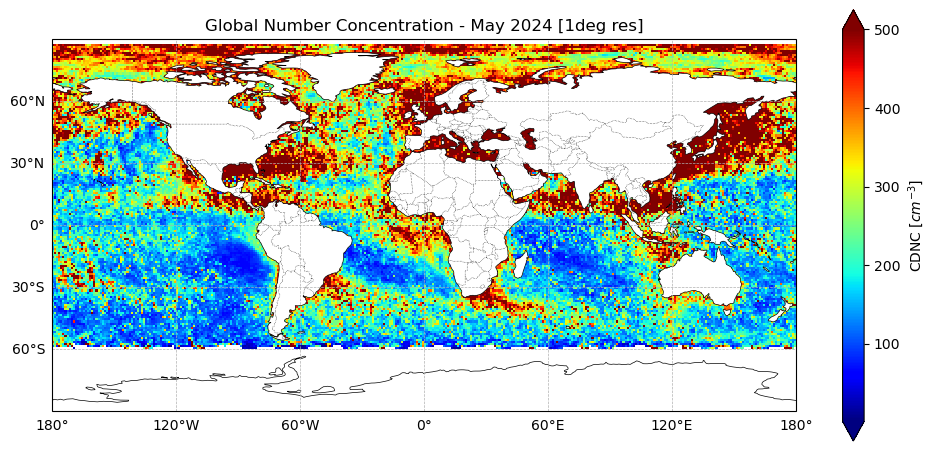

min Nd is 0.9827459750415409
max Nd is 3326.612354537251


In [22]:
Nd_monthly_mean = Nd.mean(dim='time', skipna=True)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

Nd_monthly_mean.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', vmax=500, 
                                cbar_kwargs={'label': r'CDNC [$cm^{-3}$]', 'shrink': 0.7, 'extend':'both'})

ax.coastlines(linewidth=0.5, color='k')
ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Global Number Concentration - May 2024 [1deg res]', fontsize=12)

plt.show()


print('min Nd is', np.nanmin(Nd_monthly_mean))
print('max Nd is', np.nanmax(Nd_monthly_mean))

### Nd(OCI_cot, HARP2_cer, HARP2_cev) 

In [23]:
Nd = Nd_adiabatic_model_ve(ds_O.cot_21_water, ds_H.cloud_bow_droplet_effective_radius, ds_H.cloud_bow_droplet_effective_variance)

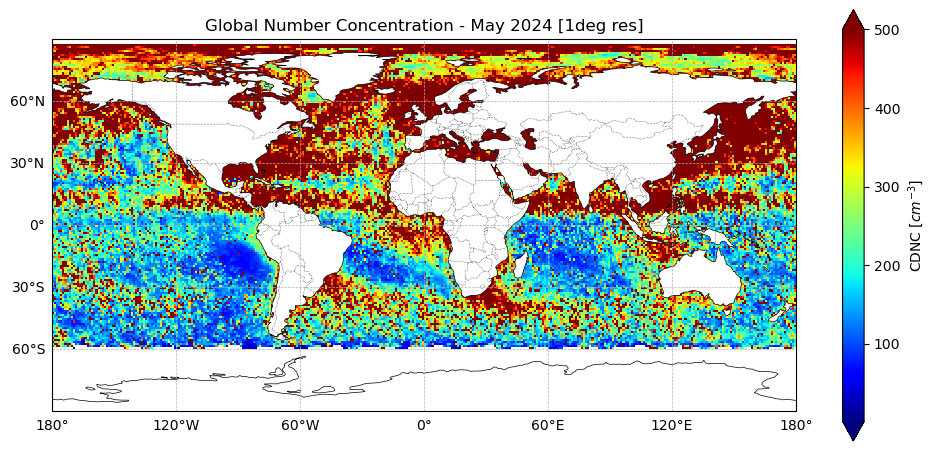

min Nd is 0.9827459750415409
max Nd is 370734.4832912059


In [24]:
Nd_monthly_mean = Nd.mean(dim='time', skipna=True)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

Nd_monthly_mean.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', vmax=500, 
                                cbar_kwargs={'label': r'CDNC [$cm^{-3}$]', 'shrink': 0.7, 'extend':'both'})

ax.coastlines(linewidth=0.5, color='k')
ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title('Global Number Concentration - May 2024 [1deg res]', fontsize=12)

plt.show()


print('min Nd is', np.nanmin(Nd_monthly_mean))
print('max Nd is', np.nanmax(Nd_monthly_mean))

##### Multi-plots 

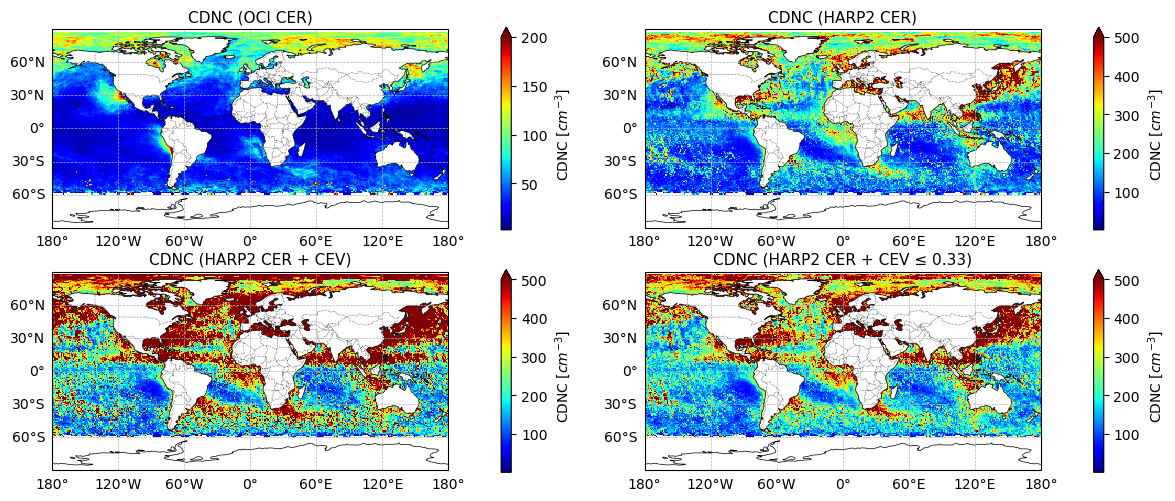

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5), subplot_kw={'projection': ccrs.PlateCarree()})

Nd1 = Nd_adiabatic_model(ds_O.cot_21_water, ds_O.cer_21_water)
Nd2 = Nd_adiabatic_model(ds_O.cot_21_water, ds_H.cloud_bow_droplet_effective_radius)
Nd3 = Nd_adiabatic_model_ve(ds_O.cot_21_water, ds_H.cloud_bow_droplet_effective_radius, 
                            ds_H.cloud_bow_droplet_effective_variance)
Nd4 = Nd_adiabatic_model_ve(ds_O.cot_21_water, ds_H.cloud_bow_droplet_effective_radius, ev_cut)

Nd_monthly_mean1 = Nd1.mean(dim='time', skipna=True)
Nd_monthly_mean2 = Nd2.mean(dim='time', skipna=True)
Nd_monthly_mean3 = Nd3.mean(dim='time', skipna=True)
Nd_monthly_mean4 = Nd4.mean(dim='time', skipna=True)

datasets = [
    (Nd_monthly_mean1, 200, 'CDNC (OCI CER)'),
    (Nd_monthly_mean2, 500, 'CDNC (HARP2 CER)'),
    (Nd_monthly_mean3, 500, 'CDNC (HARP2 CER + CEV)'),
    (Nd_monthly_mean4, 500, 'CDNC (HARP2 CER + CEV ≤ 0.33)')
]

for ax, (data, vmax, title) in zip(axes.flat, datasets):
    pcm = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', vmax=vmax, 
                               cbar_kwargs={'label': r'CDNC [$cm^{-3}$]', 'shrink': 1.0, 'pad': 0.1})

    ax.coastlines(linewidth=0.5, color='k')
    ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

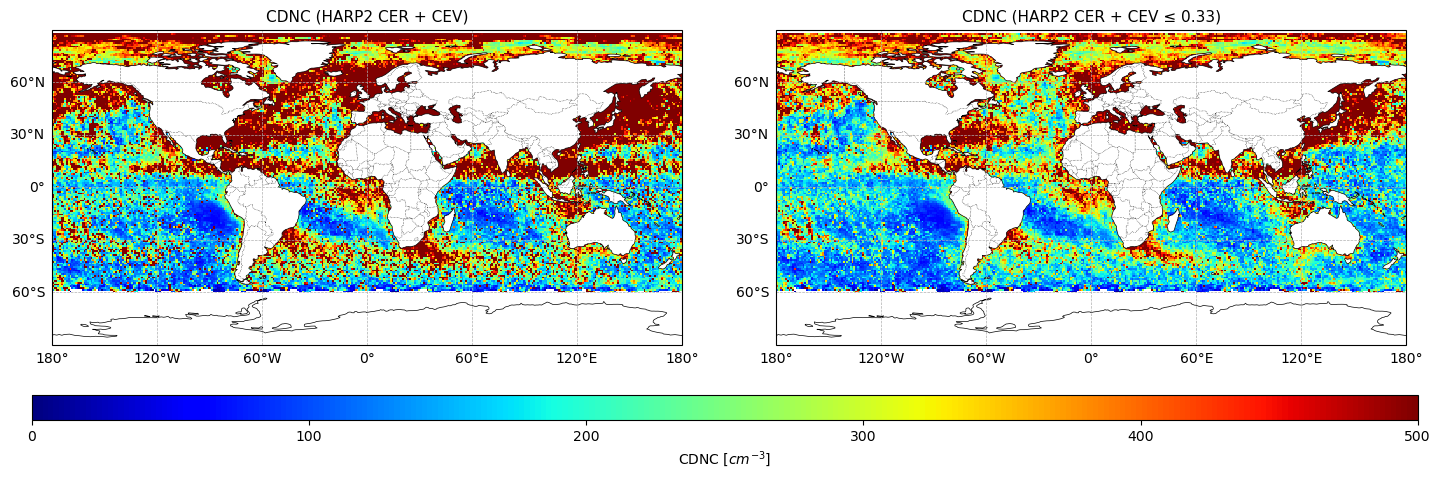

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), subplot_kw={'projection': ccrs.PlateCarree()})

Nd2 = Nd_adiabatic_model_ve(ds_O.cot_21_water, ds_H.cloud_bow_droplet_effective_radius, 
                            ds_H.cloud_bow_droplet_effective_variance)
Nd3 = Nd_adiabatic_model_ve(ds_O.cot_21_water, ds_H.cloud_bow_droplet_effective_radius, ev_cut)

Nd_monthly_mean2 = Nd2.mean(dim='time', skipna=True)
Nd_monthly_mean3 = Nd3.mean(dim='time', skipna=True)

datasets = [
    (Nd_monthly_mean2, 'CDNC (HARP2 CER + CEV)'),
    (Nd_monthly_mean3, 'CDNC (HARP2 CER + CEV ≤ 0.33)')
]

vmax = 500 
pcm_list = []

for ax, (data, title) in zip(axes, datasets):
    pcm = data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap='jet', vmin=0, vmax=vmax, 
                               add_colorbar=False)

    pcm_list.append(pcm)
    
    ax.coastlines(linewidth=0.5, color='k')
    ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    # if i == 1:
    #     gl.left_labels = False

    ax.set_title(title, fontsize=11)

fig.subplots_adjust(bottom=0.25, wspace=0.08)
cax = fig.add_axes([0.125, 0.1, 0.77, 0.05])

cbar = fig.colorbar(pcm_list[0], cax=cax, orientation='horizontal',)
cbar.set_label(r'CDNC [$cm^{-3}$]')

plt.show()

### HARP-2 L2 CDNC regridded to L3

In [27]:
bbox = (-180, -90, 180, 90) 
results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC", 
    temporal= ("2024-05-01", "2024-05-31"),
    bounding_box=bbox,
)
print(len(results))

3614


In [28]:
# files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0")

In [29]:
start_date = datetime(2024, 5, 1)
end_date   = datetime(2024, 5, 31)

files = glob.glob("/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0/*.V3_0.nc")

# Extract date from filename and filter by range
def extract_date(f):
    match = re.search(r"(\d{8})", f)
    if match:
        return datetime.strptime(match.group(1), "%Y%m%d")
    return None

paths = [f for f in files if extract_date(f) and start_date <= extract_date(f) <= end_date]
print(len(paths))

3614


In [30]:
bbox = (-180, -90, 180, 90)   

In [31]:
er = []
ev = []
cdnc = []
lat = []
lon = []

for p in paths:

    ds = open_L2_CLOUD_GPC(p, bbox)

    # filter to only aggregate the left side of the granule
    # along_dim, across_dim = ds.latitude.dims
    # ds = ds.isel({across_dim: slice(0, 309)})

    er_flat   = ds.cloud_bow_droplet_effective_radius.data.flatten()
    ev_flat   = ds.cloud_bow_droplet_effective_variance.data.flatten()
    cdnc_flat = ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()
    lwp_flat  = ds.cloud_bow_liquid_water_path.data.flatten()
    lat_flat  = ds.latitude.data.flatten()
    lon_flat  = ds.longitude.data.flatten()

    mask = (~np.isnan(er_flat) & ~np.isnan(ev_flat) & ~np.isnan(cdnc_flat) & ~np.isnan(lwp_flat))

    er.append(er_flat[mask])
    ev.append(ev_flat[mask])
    cdnc.append(cdnc_flat[mask])

    lat.append(lat_flat[mask])
    lon.append(lon_flat[mask])

In [32]:
er   = np.concatenate(er)
ev   = np.concatenate(ev)
cdnc = np.concatenate(cdnc)

lat  = np.concatenate(lat)
lon  = np.concatenate(lon)

In [33]:
lat_bins = np.arange(-90, 91, 1)
lon_bins = np.arange(-180, 181, 1)

lat_idx = np.digitize(lat, lat_bins) - 1
lon_idx = np.digitize(lon, lon_bins) - 1

cdnc_sum = np.zeros((len(lat_bins)-1, len(lon_bins)-1))
cdnc_count = np.zeros_like(cdnc_sum)

valid = ((lat_idx >= 0) & (lat_idx < cdnc_sum.shape[0]) & (lon_idx >= 0) & (lon_idx < cdnc_sum.shape[1]))

np.add.at(cdnc_sum, (lat_idx[valid], lon_idx[valid]), cdnc[valid])
np.add.at(cdnc_count, (lat_idx[valid], lon_idx[valid]), 1)

cdnc_mean = np.divide(cdnc_sum, cdnc_count, out=np.full_like(cdnc_sum, np.nan), where=cdnc_count > 0)

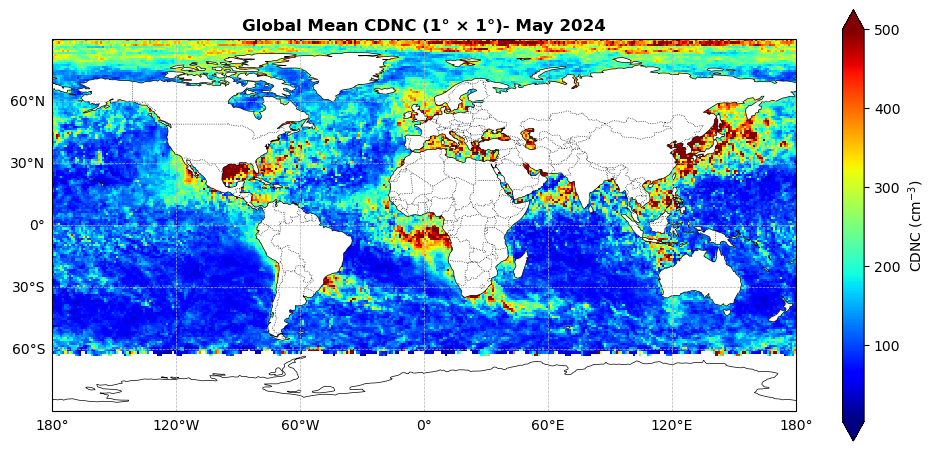

min Nd is 3.768987456957499
max Nd is 4842.0927734375


In [34]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

lon2d, lat2d = np.meshgrid(lon_bins, lat_bins)
img = ax.pcolormesh(lon2d, lat2d, cdnc_mean, transform=ccrs.PlateCarree(), cmap='jet', vmax=500)

ax.coastlines(linewidth=0.5, color='k')
ax.add_feature(cfeature.LAND, facecolor='white', zorder=1)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, zorder=2)
ax.set_title('Global Mean CDNC (1° × 1°)- May 2024', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar= plt.colorbar(img, ax=ax, shrink=0.7, extend='both')    
cbar.set_label('CDNC (cm$^{-3}$)')

plt.show()


print('min Nd is', np.nanmin(cdnc_mean))
print('max Nd is', np.nanmax(cdnc_mean))